## FLAG-X workflow, unlabeled data

In this notebook we demonstrate how FLAG-X can be used to aid and accelerate manual gating of multiple samples. This can be used to efficiently obtain initial labels for the training of supervised classification models (such as MLP classifier and SOM classifier) for fully automated gating. For details, we refer to our preprint on [bioRxiv](https://doi.org/10.64898/2026.01.10.698765).

Here, only six exemplary samples from the BLAST110 dataset published by Mocking *et al.* (2025) (see: [Zenodo](https://zenodo.org/records/11046402), [DOI](https://doi.org/10.1038/s43856-024-00700-x)) to demonstrate the following workflow:

1. Load data samples
2. Process data samples
3. SOM training
4. Dimensionality reduction
5. Export


### Import packages and define paths

In [18]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

from flagx.io import FlowDataManager, export_to_fcs
from flagx.gating import SOMClassifier
from flagx.dimred import UMAP, TSNE

plt.style.use('default')

BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'data')
SAVE_PATH = os.path.join(BASE_DIR, 'results')
os.makedirs(SAVE_PATH, exist_ok=True)


### 1.) Data loading

Load the *FCS* files corresponding to patient samples using FLAG-X's ``FlowDataManager`` class.

Supported file formats are:
- *CSV*
- *FCS*, versions **3.1**, **3.0**, **2.0**
- *LMD*, containing an *FCS3.1*, *FCS3.0*, or *FCS2.0*-compliant part

Harmonization and channel names and ordering is only partially handled by FLAG-X and must be performed manually. Each sample is expected to contain the same number of channels, in the same order, corresponding to the same markers.

For further details please refer to the [docs](https://flag-x.readthedocs.io/en/latest/).

In [19]:
# Instantiate the FlowDataManager
data_filenames = sorted([fn for fn in os.listdir(DATA_PATH) if fn.endswith('.fcs')])
fdm = FlowDataManager(
    data_file_names=data_filenames,
    data_file_path=DATA_PATH,
    save_path=None,
    verbosity=1
)

# Load the datafiles into memory; If present, use marker names (PnS) as index.
fdm.load_data_files_to_anndata(reindex=True)

# Harmonize channel names and order
mapping = {'CD34 Cy55': 'CD34', 'CD45 KO': 'CD45'}
for adata in fdm.anndata_list_:
    adata.var.index = adata.var.index.map(lambda x: mapping.get(x, x))
    spill = adata.uns['meta']['spill']
    spill.index = spill.index.to_series().replace(mapping)
    spill.columns = spill.columns.to_series().replace(mapping)
    adata.uns['meta']['spill'] = spill
common_channels = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45', 'Time', 'event_ID']
for i, adata in enumerate(fdm.anndata_list_):
    fdm.anndata_list_[i] = adata[:, common_channels].copy()


### 2.) Data processing

# Channel names:
['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45', 'Time', 'event_ID']



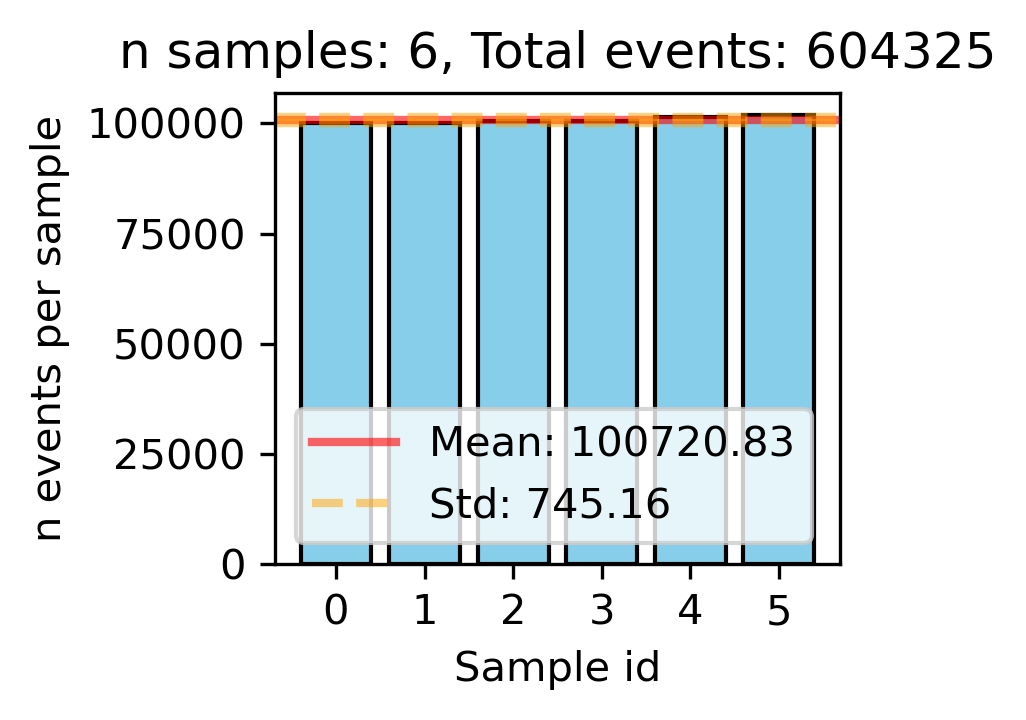

# Compensation log:
             filename                               logs
0  BLAST110_25_P1.fcs  compensation applied successfully
1  BLAST110_50_P1.fcs  compensation applied successfully
2  BLAST110_57_P1.fcs  compensation applied successfully
3  BLAST110_67_P1.fcs  compensation applied successfully
4  BLAST110_77_P1.fcs  compensation applied successfully
5  BLAST110_85_P1.fcs  compensation applied successfully


In [20]:

# Align channel names across samples, use 1st sample as reference
# Note: Harmonize channel names across samples by using the 1st file as reference for all others. Assume same channel order across samples.
fdm.align_channel_names(reference_channel_names=0)

# Check whether channel names were consistent across all samples
fdm.check_og_channel_names_df()

# Print the channel names
adata = fdm.anndata_list_[0]
print(f'# Channel names:\n{adata.var.index.tolist()}\n')

# Check the sample sizes
fdm.check_sample_sizes()
fig, ax = plt.subplots(figsize=(3, 2.5), dpi=300)
fdm.plot_sample_size_df(sample_size_df=fdm.sample_sizes_, ax=ax)
fig.tight_layout()
plt.show()
plt.close(fig)

# Apply compensation
fdm.sample_wise_compensation()
print(f'# Compensation log:\n{fdm.compensation_log_}')

# Downsample to 1000 events per sample
# Note: Aggressive downsampling is done for faster SOM training and faster UMAP and t-SNE computation. In practice more events per sample should be retained.
downsampling_bools, _ = fdm.sample_wise_downsampling(data_set='all', target_num_events=1000, stratified=False)

# Apply preprocessing transformation, choose arcsinh with a cofactor of 150, save non-transformed data to layer 'raw'
fdm.sample_wise_preprocessing(flavour='arcsinh', save_raw_to_layer='raw', cofactor=150)


### 3.) SOM training
Train the SOM component of the SOM classifier (unsupervised)

In [21]:
# Extract concatenated and shuffled data matrix for model training
# Note: We generate a data Pytorch DataLoader with batch_size=-1 (meaning all events), and extract the 1st batch.
channels = ['FSC-A', 'SSC-A', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45']
data_loader = fdm.get_data_loader(
    data_set='all',
    channels=channels,
    batch_size=-1,
    shuffle=True,
    return_data_loader='np_array',
)
x_train = next(iter(data_loader))

# Create dummy label vector
y_train = np.full(x_train.shape[0], -999)

# Instantiate the SOM classifier
som_clf = SOMClassifier(
    som_topology='planar',
    som_grid_type='rectangular',
    som_dimensions=(10, 10),
    neighborhood='gaussian',
    gaussian_neighborhood_sigma=0.1,
    initialization='pca',
    n_epochs=20,
    radius_0=-0.5,
    radius_n=0.1,
    radius_cooling='exponential',
    learning_rate_0=0.1,
    learning_rate_n=0.001,
    learning_rate_decay='exponential',
    unlabeled_label=-999,
    verbosity=1
)

# Fit
som_clf.fit(X=x_train, y=y_train)




    100% [===================================================]


Time for epoch 1: 0.06437 Time for epoch 2: 0.04281 Time for epoch 3: 0.05449 Time for epoch 4: 0.03635 Time for epoch 5: 0.02366 Time for epoch 6: 0.0178 Time for epoch 7: 0.02468 Time for epoch 8: 0.01728 Time for epoch 9: 0.03974 Time for epoch 10: 0.03993 Time for epoch 11: 0.03179 Time for epoch 12: 0.02136 Time for epoch 13: 0.0253 Time for epoch 14: 0.01442 Time for epoch 15: 0.003064 Time for epoch 16: 0.007533 Time for epoch 17: 0.01214 Time for epoch 18: 0.007578 Time for epoch 19: 0.004547 Time for epoch 20: 0.007324 /mnt/c/Users/paulm/PycharmProjects/FLAG-X/flagx/gating/som_classifier.py:230: UserWarning: No labeled data provided. Only the SOM component is trained in an unsupervised fashion.
  warnings.warn(


,som_topology,'planar'
,som_grid_type,'rectangular'
,som_dimensions,"(10, ...)"
,neighborhood,'gaussian'
,gaussian_neighborhood_sigma,0.1
,initialization,'pca'
,initial_codebook,None
,n_epochs,20
,radius_0,5.0
,radius_n,0.1
,radius_cooling,'exponential'


### 4.) Dimensionality reduction

In [22]:

# Extract data matrices (arcsinh transformed and non-transformed) without shuffling and keep track of sample IDs
data_matrices = []
data_matrices_raw = []
sample_ids = []
filenames = []
for i, adata in enumerate(fdm.anndata_list_):
    data_matrices.append(adata[:, channels].X.copy())
    data_matrices_raw.append(adata[:, channels].layers['raw'].copy())
    sample_ids.append(np.full(adata.shape[0], i))
    filenames.append(adata.uns['filename'])
x_ordered = np.concatenate(data_matrices, axis=0)
x_ordered_raw = np.concatenate(data_matrices_raw, axis=0)
y_sample_id = np.concatenate(sample_ids, axis=0)

_, x_som, _, _ = som_clf.transform(x_ordered)

reducer_umap = UMAP(n_components=2, n_jobs=-1)
x_umap = reducer_umap.fit_transform(x_ordered)

reducer_tsne = TSNE(n_components=2, n_jobs=-1)
x_tsne = reducer_tsne.fit_transform(x_ordered)


### 5.) Export

In [23]:

# Create dataframe with data to be exported and channel names as columns
x_ordered_raw_df = pd.DataFrame(x_ordered_raw, columns=channels)

# Export
export_to_fcs(
    data_list=[ad.AnnData(x_ordered_raw_df), ],
    sample_wise=True,
    add_columns=[
        [x_som[:, 0], ], [x_som[:, 1], ],
        [x_umap[:, 0], ], [x_umap[:, 1], ],
        [x_tsne[:, 0], ], [x_tsne[:, 1], ],
        [y_sample_id, ]
    ],
    add_columns_names=['SOM1', 'SOM2', 'UMAP1', 'UMAP2', 'TSNE1', 'TSNE2', 'sample_ID'],
    scale_columns=['SOM1', 'SOM2', 'UMAP1', 'UMAP2', 'TSNE1', 'TSNE2', 'sample_ID'],
    val_range=(0.0, 2.0**20),
    keep_unscaled=False,
    save_path=SAVE_PATH,
    save_filenames=['workflow_unsupervised_export.fcs', ]
)

# Additionally, save the mapping from filenames to sample IDs
df = pd.DataFrame({'filename': filenames, 'sample_ID': list(range(len(filenames)))})
df.to_csv(os.path.join(SAVE_PATH, 'workflow_unsupervised_export.csv'), index=False)


/home/paulm/miniforge3/envs/flagx-test/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


### Load and process annotation data for visualization

The main workflow is finished after the export of the annotated data samples. Manual gating is subsequently performed on the exported file, using the learned 2D representations (SOM, UMAP, t-SNE) to support the assignment of population labels.

For the sake of completeness, we visualize the results in Python. Shown population labels were provided by Mocking *et al.* (2025) (see: [Zenodo](https://zenodo.org/records/11046402), [DOI](https://doi.org/10.1038/s43856-024-00700-x)) where blasts were gated as follows:
- WBC based on FSC-A, SSC-A
- WBC/Singlets based on FSC-A, FSC-H
- WBC/Singlets/CD45pos based on SSC-A, CD45
- WBC/Singlets/CD45pos/Lymphocytes based on SSC-A, CD45
- WBC/Singlets/CD45pos/CD45dim based on SSC-A, CD45; shown in green in (**D**)
- WBC/Singlets/CD45pos/CD45dim/CD34pos based on SSC-A, CD34; shown in green in (**E**)
- WBC/Singlets/CD45pos/CD45dim/CD117pos based on SSC-A, CD117; shown in green in (**F**)

Blasts are defined as the combination of the CD34pos and CD117pos populations. Shown in green in (**A**), (**B**), and (**C**).


In [24]:
# Load annotation data with blast labels
label_dfs = []
for fn in data_filenames:
    label_df = pd.read_csv(os.path.join(DATA_PATH, fn[:-4]+ '.csv'), index_col=0)
    label_dfs.append(label_df)

# Downsample and extract blast annotations from annotation dataframes
y_blasts = []  # WBC, CD45dim, CD34pos or CD117pos
y_wbc_cd45dims = []
y_wbc_cd45dim_cd34positives = []
y_wbc_cd45dim_cd117positives = []
for i, (ds_bool, label_df) in enumerate(zip(downsampling_bools, label_dfs)):
    y_blasts.append(label_df['Blast'].to_numpy()[ds_bool])
    y_wbc_cd45dims.append(label_df['WBC/CD45dim'].to_numpy()[ds_bool])
    y_wbc_cd45dim_cd34positives.append(label_df['WBC/CD45dim/CD34pos'].to_numpy()[ds_bool])
    y_wbc_cd45dim_cd117positives.append(label_df['WBC/CD45dim/CD117pos'].to_numpy()[ds_bool])

y_blast = np.concatenate(y_blasts)
y_wbc_cd45dim = np.concatenate(y_wbc_cd45dims)
y_wbc_cd45dim_cd34pos = np.concatenate(y_wbc_cd45dim_cd34positives)
y_wbc_cd45dim_cd117pos = np.concatenate(y_wbc_cd45dim_cd117positives)


### Visualize results in Python

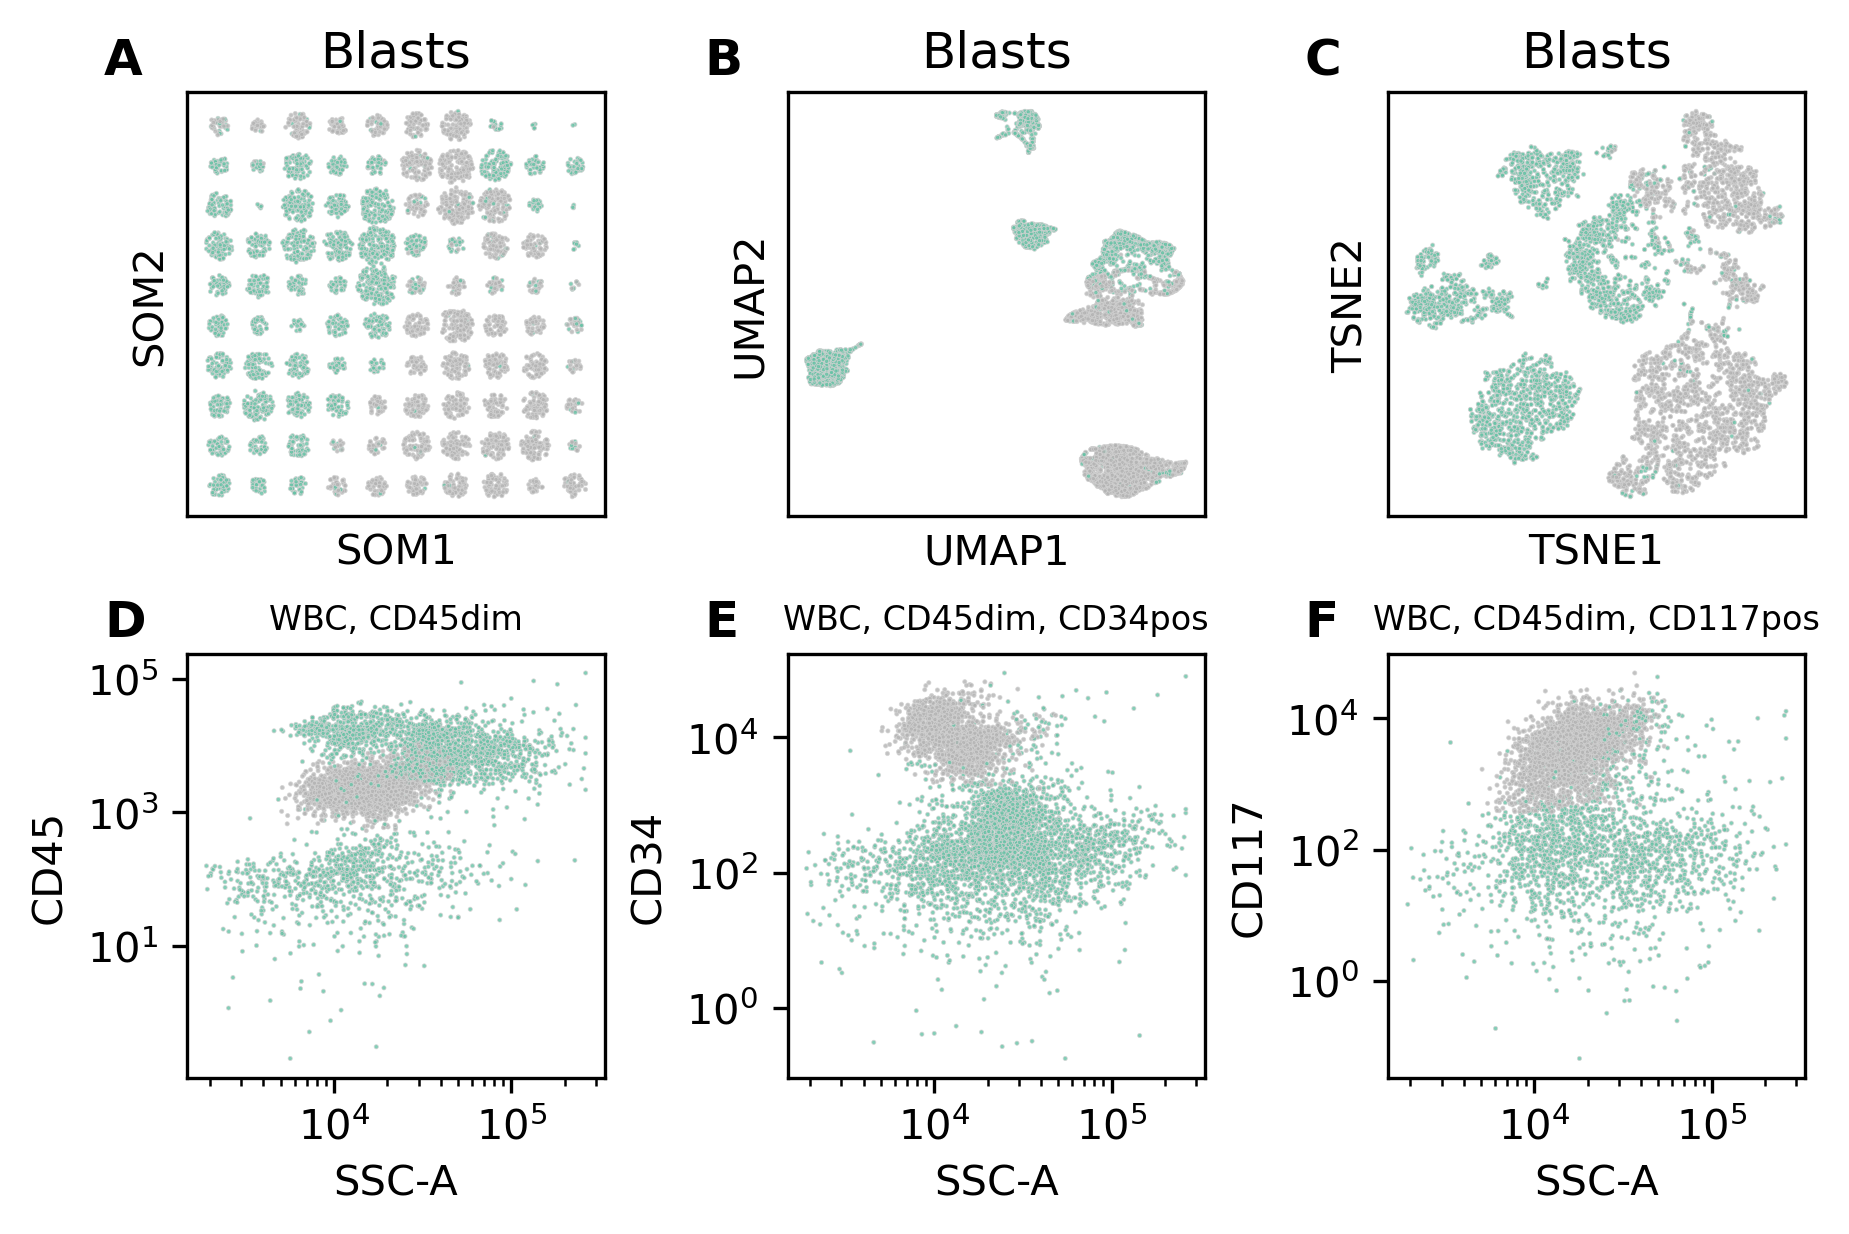

In [25]:

fig, axd = plt.subplot_mosaic(
    '''
    ABC
    DEF
    ''',
    figsize=(6, 4),
    dpi=300,
    constrained_layout=True,
)

marker_size = 1.0

for key, name, x in zip(list('ABC'), ['SOM', 'UMAP', 'TSNE'], [x_som, x_umap, x_tsne]):

    ax = axd[key]
    ax.scatter(
        x[:, 0],
        x[:, 1],
        s=marker_size,
        c=y_blast,
        cmap='Set2',
        edgecolors='lightgrey',
        linewidths=0.2,
        alpha=0.8,
    )
    ax.set_xlabel(f'{name}1')
    ax.set_ylabel(f'{name}2')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Blasts')

# 'FSC-A', 'SSC-A', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45 KO'
marker_combinations = [('SSC-A', 'CD45'), ('SSC-A', 'CD34'), ('SSC-A', 'CD117')]
y_cols = [y_wbc_cd45dim, y_wbc_cd45dim_cd34pos, y_wbc_cd45dim_cd117pos]
titles = ['WBC, CD45dim', 'WBC, CD45dim, CD34pos', 'WBC, CD45dim, CD117pos']

for key, (marker0, marker1), y_col, title in zip(list('DEF'), marker_combinations, y_cols, titles):
    ax = axd[key]
    ax.scatter(
        x_ordered_raw_df[marker0].to_numpy(),
        x_ordered_raw_df[marker1].to_numpy(),
        s=marker_size,
        c=y_col,
        cmap='Set2',
        edgecolors='lightgrey',
        linewidths=0.2,
        alpha=0.8,
    )
    ax.set_xlabel(marker0)
    ax.set_ylabel(marker1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(False)
    ax.set_title(title, fontsize=8)

for label, ax in axd.items():
    trans = mtransforms.ScaledTranslation(-20 / 72, 7 / 72, fig.dpi_scale_trans)
    ax.text(0.0, 0.95, label, transform=ax.transAxes + trans, fontsize=12, va='bottom', fontfamily='sans-serif', fontweight='bold')

plt.show()
